# NOTAS

Probar hacer subclases para svm y qsvm para que cada una pueda tener su dataset con su propia técnica

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

from pandas import read_csv, DataFrame, concat

from numpy import arange, full, nan, size, shape, pi, identity, array

from seaborn import heatmap

import os

import matplotlib.pyplot as plt

from qiskit.circuit.library import z_feature_map, unitary_overlap, zz_feature_map
import qnexus as qnx
import numpy as np

from pytket.extensions.qiskit import qiskit_to_tk

# --- config ---

DATA_PATH = os.path.join('..', 'data', "water_potability.csv")
RANDOM_SEED = 42


NUM_MUESTRAS_ENTRENAMIENTO = [24] #8 * arange(start = 1, stop = 2, dtype=int) 
PCA_DIMENTIONS = [2]
FEATURE_MAPS = [z_feature_map]
USAR_MATRICES_PRECOMPUTADAS = True
NUM_SHOTS = 1000

qnx.login()

project = qnx.projects.get_or_create(
    name="Water Potability QSVM"
)

qnx.context.set_active_project(project)

backend = qnx.QuantinuumConfig(
    device_name="H2-Emulator"
)

Already logged in. Tokens are valid.


In [ ]:
class qsvm:
    
    # --- data ---

    x = 0
    y = 0

    x_train = 0
    x_test = 0
    
    y_train = 0
    y_test = 0

    x_train_scaled = 0
    x_test_scaled = 0
    
    # --- qsvm

    qsvm = SVC( kernel = 'precomputed') 
    q_kernel = {}
    q_x_test = {}

    
    def getData(self, num_muestras):
        
        data = read_csv(DATA_PATH)
            
        data = data.dropna() # hay que limpiar los NaN, si no el normalizar no tiene sentido
        
        data = data.sample(frac=1,\
                           random_state=RANDOM_SEED)
        
        potable_data = data.loc[data['Potability']==1]
        
        unpotable_data = data.loc[data['Potability']==0]
        
        muestras = int((num_muestras/.8)/2)
        
        data = concat([potable_data.iloc[0:muestras], \
                       unpotable_data.iloc[0:muestras]])
        
        
        data = data.sample(frac = 1, \
                           random_state=RANDOM_SEED)
        
        '''
        
        Hay que ver si se ponen nuevas features
        
        '''
        
        '''
        El documento dice
        
        Imputar valores faltantes (pH: 491 NaN; Sulfato: 781 NaN; Trihalometanos: 162 NaN) por mediana por clase.
        
        Pero no sé si hay que hacer caso a eso xd
        
        '''
        
        potability = data["Potability"]
        
        data = data.drop("Potability", axis = 1) # quitar potabilidad
   
        self.x = data
        self.y = potability

    def proccess_data(self, dim):
        
        data_train, data_test, potability_train, potability_test = \
        train_test_split(self.x, self.y, test_size=.2, random_state=RANDOM_SEED)
        
        self.x_train = data_train
        self.x_test = data_test
        
        scaler = StandardScaler()
        
        data_train_scaled = scaler.fit_transform(data_train)
        data_test_scaled = scaler.transform(data_test)

        if dim != 9:
        
            pca = PCA(n_components = dim, random_state = RANDOM_SEED)
            
            data_train_scaled = pca.fit_transform(data_train_scaled)
            
            data_test_scaled = pca.transform(data_test_scaled)

        self.x_train_scaled = data_train_scaled
        self.x_test_scaled = data_test_scaled
        
        self.y_train = potability_train 
        self.y_test = potability_test


    def test(self):

        x = self.q_x_test
        y = self.y_test
        
        svm = self.qsvm

        y_pred = svm.predict(x)
        
        print(f'Confusion matrix: \n {confusion_matrix(y, y_pred)}\n')
        print(f'Accuracy = {accuracy_score(y, y_pred):.2f}')
        print(f'Clasification report: \n {classification_report(y, \
        y_pred, target_names=['Non-Potable' , 'Potable'])}')        

        print(f'Real y = {list(y)}')
        print(f'Prediction = {y_pred}')
        

    def generar_qsmv(self, fm_function):

        x_train = self.x_train_scaled
        y_train = self.y_train

        fm = fm_function(
            feature_dimension=x_train.shape[1]
        )

        train_size = x_train.shape[0]

        kernel_matrix = identity(train_size)

        num_shots = NUM_SHOTS

        # ==========================================================
        # TRAINING KERNEL
        # ==========================================================

        programs = []
        pairs = []

        for x1 in range(train_size):
            for x2 in range(x1 + 1, train_size):

                unitary1 = fm.assign_parameters(x_train[x1])
                unitary2 = fm.assign_parameters(x_train[x2])

                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()

                tk_overlap = qiskit_to_tk(overlap_circ)

                program = qnx.circuits.upload(
                    circuit=tk_overlap,
                    name=f"kernel_{x1}_{x2}",
                )

                programs.append(program)
                pairs.append((x1, x2))

        BATCH_SIZE = 100

        for batch_start in range(0, len(programs), BATCH_SIZE):

            batch_programs = programs[batch_start:batch_start + BATCH_SIZE]
            batch_pairs = pairs[batch_start:batch_start + BATCH_SIZE]

            compile_job = qnx.start_compile_job(
                programs=batch_programs,
                backend_config=backend,
                optimisation_level=2,
                name=f"compile_kernel_batch_{batch_start}",
            )

            qnx.jobs.wait_for(compile_job)

            compiled = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]

            execute_job = qnx.start_execute_job(
                programs=compiled,
                n_shots=[num_shots] * len(compiled),
                backend_config=backend,
                name=f"execute_kernel_batch_{batch_start}",
            )

            qnx.jobs.wait_for(execute_job)

            results = qnx.jobs.results(execute_job)

            for pair, result in zip(batch_pairs, results):

                distribution = result.download_result().get_distribution()

                n_bits = len(next(iter(distribution)))
                zero_state = (0,) * n_bits

                prob_zero = distribution.get(zero_state, 0)

                x1, x2 = pair

                kernel_matrix[x1, x2] = prob_zero
                kernel_matrix[x2, x1] = prob_zero

        np.fill_diagonal(kernel_matrix, 1)

        # ==========================================================
        # TEST KERNEL
        # ==========================================================

        x_test = self.x_test_scaled

        test_size = x_test.shape[0]

        test_matrix = full((test_size, train_size), nan)

        programs = []
        pairs = []

        for xt in range(test_size):
            for xr in range(train_size):

                unitary1 = fm.assign_parameters(x_test[xt])
                unitary2 = fm.assign_parameters(x_train[xr])

                overlap_circ = unitary_overlap(unitary1, unitary2)
                overlap_circ.measure_all()

                tk_overlap = qiskit_to_tk(overlap_circ)

                program = qnx.circuits.upload(
                    circuit=tk_overlap,
                    name=f"test_{xt}_{xr}",
                )

                programs.append(program)
                pairs.append((xt, xr))

        for batch_start in range(0, len(programs), BATCH_SIZE):

            batch_programs = programs[batch_start:batch_start + BATCH_SIZE]
            batch_pairs = pairs[batch_start:batch_start + BATCH_SIZE]

            compile_job = qnx.start_compile_job(
                programs=batch_programs,
                backend_config=backend,
                optimisation_level=2,
                name=f"compile_test_batch_{batch_start}",
            )

            qnx.jobs.wait_for(compile_job)

            compiled = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]

            execute_job = qnx.start_execute_job(
                programs=compiled,
                n_shots=[num_shots] * len(compiled),
                backend_config=backend,
                name=f"execute_test_batch_{batch_start}",
            )

            qnx.jobs.wait_for(execute_job)

            results = qnx.jobs.results(execute_job)

            for pair, result in zip(batch_pairs, results):

                distribution = result.download_result().get_counts()

                n_bits = len(next(iter(distribution)))
                zero_state = (0,) * n_bits

                prob_zero = distribution.get(zero_state, 0)

                xt, xr = pair

                test_matrix[xt, xr] = prob_zero

        qsvm = SVC(kernel="precomputed")
        qsvm.fit(kernel_matrix, y_train)

        self.q_kernel = kernel_matrix
        self.q_x_test = test_matrix
        self.qsvm = qsvm


    def guardar(self, name):

        k_path = os.path.join('..', 'data', 'kernel', f'{name}.csv')
        test_path = os.path.join('..', 'data', 'test', f'{name}.csv')
        
        DataFrame(self.q_kernel).to_csv(k_path)
        
        DataFrame(self.q_x_test).to_csv(test_path)


        print(f'Guardando {name}\n')

# QSVM

## Quantum Kernel

In [12]:
qsvm = qsvm()

Procesando n_24_dim_2_z_feature_map


C:\Users\maxru\AppData\Local\Temp\ipykernel_16572\4284264364.py:189: DeprecationWarning: The `BackendResult.get_distribution()` method is deprecated: please use `get_empirical_distribution()` or `get_probability_distribution()` instead.
  distribution = result.download_result().get_distribution()
C:\Users\maxru\AppData\Local\Temp\ipykernel_16572\4284264364.py:267: DeprecationWarning: The `BackendResult.get_distribution()` method is deprecated: please use `get_empirical_distribution()` or `get_probability_distribution()` instead.
  distribution = result.download_result().get_distribution()


Matrices precomputadas no encontradas
Confusion matrix: 
 [[1 1]
 [1 3]]

Accuracy = 0.67
Clasification report: 
               precision    recall  f1-score   support

 Non-Potable       0.50      0.50      0.50         2
     Potable       0.75      0.75      0.75         4

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6

Real y = [1, 0, 0, 1, 1, 1]
Prediction = [1 1 0 0 1 1]


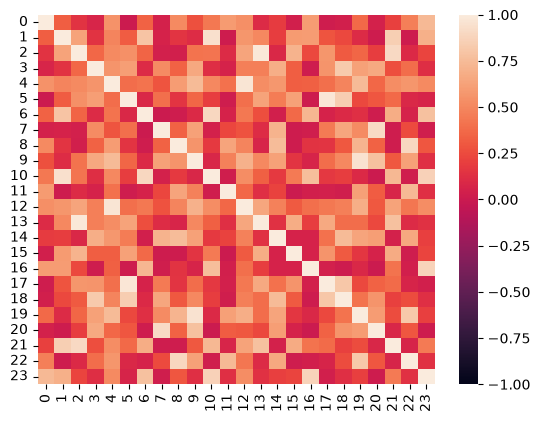

Guardando n_24_dim_2_z_feature_map



In [13]:
for fm in FEATURE_MAPS:
    for dim in PCA_DIMENTIONS:
        for n in NUM_MUESTRAS_ENTRENAMIENTO:

            encontradas = False
            
            path = '_'.join(['n', f'{n}', 'dim', f'{dim}', f'{fm.__name__}'])

            print(f'Procesando {path}')
            
            qsvm.getData(n)
            qsvm.proccess_data(dim)

            if USAR_MATRICES_PRECOMPUTADAS == True:

                k_path = os.path.join('..', 'data', 'kernel', f'{path}.csv')
                test_path = os.path.join('..', 'data', 'test', f'{path}.csv')

                try:
                    
                    qsvm.q_kernel = read_csv(k_path)
                    qsvm.q_kernel = qsvm.q_kernel.drop('Unnamed: 0', axis = 1)
                    qsvm.q_x_test = read_csv(test_path)
                    qsvm.q_x_test = qsvm.q_x_test.drop('Unnamed: 0', axis = 1)

                    qsvm.qsvm.fit(qsvm.q_kernel, qsvm.y_train)

                    encontradas = True

                    print('Procesamiento con matrices precomputadas listo')
                    
                except FileNotFoundError:
                    
                    qsvm.getData(n)
                    qsvm.proccess_data(dim)
                    qsvm.generar_qsmv(fm)

                    print('Matrices precomputadas no encontradas')

            else:

                
                
                
                qsvm.generar_qsmv(fm)

                print('Kernel generado')

            qsvm.test()
                    
            heatmap(qsvm.q_kernel, vmax=1, vmin=-1)
            plt.show()
            
            if encontradas == False:
                qsvm.guardar(path)

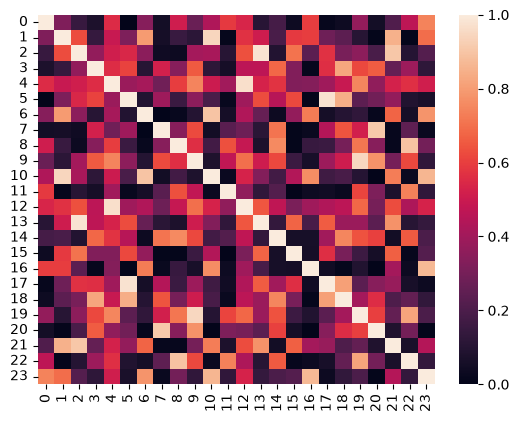

In [14]:
heatmap(qsvm.q_kernel, vmax=1, vmin=0)
plt.show()